In [60]:
import os, re, gzip, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, GATConv
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics import (roc_auc_score, f1_score,
                              average_precision_score, confusion_matrix)
from sklearn.model_selection import StratifiedKFold

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


In [59]:
# ── MTB H37Rv gene regions (23-gene catalogue from the paper) ──────────────
MTB_GENE_REGIONS = {
    "katG":  ("NC_000962.3",  2153889, 2156111),
    "fabG1": ("NC_000962.3",  1673280, 1674183),
    "inhA":  ("NC_000962.3",  1674202, 1675011),
    "ahpC":  ("NC_000962.3",  2726105, 2726950),
    "rpoB":  ("NC_000962.3",   759807,  763325),
    "rpoC":  ("NC_000962.3",   763370,  767320),
    "embA":  ("NC_000962.3",  4243310, 4245330),
    "embB":  ("NC_000962.3",  4246514, 4249810),
    "embC":  ("NC_000962.3",  4240713, 4243311),
    "pncA":  ("NC_000962.3",  2288681, 2289241),
    "gyrA":  ("NC_000962.3",     7301,    9818),
    "gyrB":  ("NC_000962.3",     5240,    7267),
    "rrs":   ("NC_000962.3",  1471846, 1473382),
    "rrl":   ("NC_000962.3",  1473382, 1475491),
    "eis":   ("NC_000962.3",  2714065, 2715698),
    "gidB":  ("NC_000962.3",  4407590, 4408192),
    "tlyA":  ("NC_000962.3",  1917960, 1918590),
    "iniB":  ("NC_000962.3",  3985480, 3987076),
    "iniA":  ("NC_000962.3",  3987102, 3988602),
    "iniC":  ("NC_000962.3",  3988727, 3989990),
    "ndh":   ("NC_000962.3",  2102479, 2103985),
    "manB":  ("NC_000962.3",  4155253, 4156591),
    "rmlD":  ("NC_000962.3",  4154020, 4155231),
}

def _open_vcf(path):
    return gzip.open(path, "rt") if str(path).endswith(".gz") else open(path, "r")

def _gt_to_af(gt: str) -> float:
    alleles = re.split(r"[/|]", gt)
    try:
        return sum(1 for a in alleles if a not in ("0", ".")) / len(alleles)
    except Exception:
        return 0.0

def _extract_af(info, parts, header):
    m = re.search(r"AF=([0-9.]+)", info)
    if m:
        return float(m.group(1))
    if len(parts) >= 10 and len(header) >= 10:
        fmt = parts[8].split(":") if len(parts) > 8 else []
        gt_data = parts[9].split(":") if len(parts) > 9 else []
        if fmt and gt_data:
            gi = fmt.index("GT") if "GT" in fmt else 0
            return _gt_to_af(gt_data[gi]) if gi < len(gt_data) else 0.0
    return 0.0

def _pos_to_gene(chrom, pos, gene_regions):
    for gene, (g_chrom, start, end) in gene_regions.items():
        if chrom == g_chrom and start <= pos < end:
            return gene
    return None

def parse_single_sample_vcf(vcf_path, isolate_id,
                             gene_regions=None,
                             min_qual=20.0, min_af=0.75):
    gene_regions = gene_regions or MTB_GENE_REGIONS
    records = []
    with _open_vcf(vcf_path) as fh:
        header = []
        for line in fh:
            if line.startswith("##"):
                continue
            if line.startswith("#CHROM"):
                header = line.strip().split("\t")
                continue
            parts = line.strip().split("\t")
            if len(parts) < 8:
                continue
            chrom, pos, _, ref, alt, qual, _, info = parts[:8]
            pos = int(pos)
            try:
                if float(qual) < min_qual:
                    continue
            except ValueError:
                pass
            if len(ref) != 1 or len(alt) != 1 or alt == ".":
                continue
            if _extract_af(info, parts, header) < min_af:
                continue
            gene = _pos_to_gene(chrom, pos, gene_regions)
            if gene is None:
                continue
            records.append((isolate_id, f"{gene}_{ref}{pos}{alt}", gene))
    return records

def parse_multisample_vcf(vcf_path, gene_regions=None, min_qual=20.0, min_af=0.75):
    gene_regions = gene_regions or MTB_GENE_REGIONS
    records = []
    with _open_vcf(vcf_path) as fh:
        samples = []
        for line in fh:
            if line.startswith("##"):
                continue
            if line.startswith("#CHROM"):
                samples = line.strip().split("\t")[9:]
                continue
            parts = line.strip().split("\t")
            if len(parts) < 9 + len(samples):
                continue
            chrom, pos, _, ref, alt, qual, _, info, fmt = parts[:9]
            pos = int(pos)
            try:
                if float(qual) < min_qual:
                    continue
            except ValueError:
                pass
            if len(ref) != 1 or len(alt) != 1 or alt == ".":
                continue
            gene = _pos_to_gene(chrom, pos, gene_regions)
            if gene is None:
                continue
            fmt_fields = fmt.split(":")
            gt_idx = fmt_fields.index("GT") if "GT" in fmt_fields else 0
            af_idx = fmt_fields.index("AF") if "AF" in fmt_fields else None
            snp_id = f"{gene}_{ref}{pos}{alt}"
            for i, sample in enumerate(samples):
                gd = parts[9 + i].split(":")
                af = _gt_to_af(gd[gt_idx])
                if af_idx and len(gd) > af_idx:
                    try: af = float(gd[af_idx])
                    except ValueError: pass
                if af >= min_af:
                    records.append((sample, snp_id, gene))
    return records

def load_vcf_directory(vcf_dir, gene_regions=None, pattern="*.vcf*",
                        min_qual=20.0, min_af=0.75):
    gene_regions = gene_regions or MTB_GENE_REGIONS
    vcfs = sorted(Path(vcf_dir).glob(pattern))
    if not vcfs:
        raise FileNotFoundError(f"No VCFs matching '{pattern}' in {vcf_dir}")
    all_records = []
    for vcf_path in vcfs:
        iso_id = vcf_path.name.replace(".vcf.gz", "").replace(".vcf", "")
        recs = parse_single_sample_vcf(vcf_path, iso_id, gene_regions, min_qual, min_af)
        all_records.extend(recs)
        print(f"  {iso_id}: {len(recs)} SNPs")
    df = pd.DataFrame(all_records, columns=["isolate_id", "snp_id", "gene"])
    print(f"\nLoaded: {df['isolate_id'].nunique()} isolates, {df['snp_id'].nunique()} unique SNPs")
    return df

print("VCF parsing functions defined.")

VCF parsing functions defined.


In [44]:
# ── CONFIG: 2024 CRyPTIC inputs (first-line drugs only) ────────────────────
VCF_DIR       = "./vcf(2024)"
PHENOTYPE_CSV = "./CRyPTIC_reuse_table_20240917.csv"

# First-line TB drugs (use available columns from the phenotype table).
FIRST_LINE_CANDIDATES = [
    "INH_BINARY_PHENOTYPE",
    "RIF_BINARY_PHENOTYPE",
    "EMB_BINARY_PHENOTYPE",
    "PZA_BINARY_PHENOTYPE",
]
pheno_columns = pd.read_csv(PHENOTYPE_CSV, nrows=0).columns.tolist()
DRUG_COLS = [c for c in FIRST_LINE_CANDIDATES if c in pheno_columns]
if not DRUG_COLS:
    raise ValueError("No first-line drug columns found in phenotype table.")
print("Using first-line drugs:", DRUG_COLS)

isolate_snp_df = load_vcf_directory(VCF_DIR, min_qual=20.0, min_af=0.75)
isolate_snp_df.head()

Using first-line drugs: ['INH_BINARY_PHENOTYPE', 'RIF_BINARY_PHENOTYPE', 'EMB_BINARY_PHENOTYPE']
  ERS1987021: 11 SNPs
  ERS1987022: 11 SNPs
  ERS1987023: 11 SNPs
  ERS1987024: 4 SNPs
  ERS1987025: 11 SNPs
  ERS1987026: 14 SNPs
  ERS1987027: 13 SNPs
  ERS1987028: 10 SNPs
  ERS1987029: 9 SNPs
  ERS1987030: 9 SNPs
  ERS1987031: 15 SNPs
  ERS1987032: 12 SNPs
  ERS1987033: 11 SNPs
  ERS1987034: 11 SNPs
  ERS1987035: 8 SNPs
  ERS1987036: 11 SNPs
  ERS1987037: 12 SNPs
  ERS1987038: 9 SNPs
  ERS1987039: 9 SNPs
  ERS1987040: 10 SNPs
  ERS1987041: 15 SNPs
  ERS1987042: 15 SNPs
  ERS1987043: 16 SNPs
  ERS1987044: 10 SNPs
  ERS1987045: 9 SNPs
  ERS1987046: 16 SNPs
  ERS1987047: 11 SNPs
  ERS1987048: 11 SNPs
  ERS1987049: 13 SNPs
  ERS1987050: 12 SNPs
  ERS1987051: 11 SNPs
  ERS1987052: 12 SNPs
  ERS1987053: 10 SNPs
  ERS1987054: 13 SNPs
  ERS1987055: 13 SNPs
  ERS1987056: 7 SNPs
  ERS1987057: 7 SNPs
  ERS1987059: 10 SNPs
  ERS1987060: 18 SNPs
  ERS1987061: 11 SNPs
  ERS1987062: 10 SNPs
  ERS19870

,isolate_id,snp_id,gene
0,ERS1987021,gyrA_G7362C,gyrA
1,ERS1987021,gyrA_G7585C,gyrA
2,ERS1987021,gyrA_G9304A,gyrA
3,ERS1987021,rpoB_C760115T,rpoB
4,ERS1987021,rpoB_A760555G,rpoB


In [45]:
phenotype_raw = pd.read_csv(PHENOTYPE_CSV)

if "ENA_SAMPLE" not in phenotype_raw.columns:
    raise KeyError("Expected ENA_SAMPLE column in phenotype table.")

missing_drug_cols = [c for c in DRUG_COLS if c not in phenotype_raw.columns]
if missing_drug_cols:
    raise KeyError(f"Missing phenotype columns: {missing_drug_cols}")

# Build model-ready phenotype table with isolate_id aligned to VCF filenames.
phenotype_df = phenotype_raw[["ENA_SAMPLE", *DRUG_COLS]].copy()
phenotype_df = phenotype_df.rename(columns={"ENA_SAMPLE": "isolate_id"})

# Strict binary mapping: R -> 1, S -> 0, I/NA/other -> NaN.
label_map = {"R": 1.0, "S": 0.0}
for col in DRUG_COLS:
    phenotype_df[col] = (
        phenotype_df[col]
        .astype(str)
        .str.strip()
        .str.upper()
        .map(label_map)
        .astype(float)
    )

vcf_isolates = set(isolate_snp_df["isolate_id"].unique())
pheno_isolates = set(phenotype_df["isolate_id"].unique())
overlap = len(vcf_isolates & pheno_isolates)

print("Phenotype shape:", phenotype_df.shape)
print("VCF isolates:", len(vcf_isolates))
print("Phenotype isolates:", len(pheno_isolates))
print("Overlap isolates:", overlap)
print("\nMissing rates after strict mapping (I/NA become NaN):")
print(phenotype_df[DRUG_COLS].isna().mean().round(3))
print("\nClass distribution (R=1, S=0):")
print(phenotype_df[DRUG_COLS].apply(lambda c: c.value_counts(dropna=False)).fillna(0).astype(int))

Phenotype shape: (12287, 4)
VCF isolates: 12279
Phenotype isolates: 12287
Overlap isolates: 12279

Missing rates after strict mapping (I/NA become NaN):
INH_BINARY_PHENOTYPE    0.018
RIF_BINARY_PHENOTYPE    0.015
EMB_BINARY_PHENOTYPE    0.138
dtype: float64

Class distribution (R=1, S=0):
     INH_BINARY_PHENOTYPE  RIF_BINARY_PHENOTYPE  EMB_BINARY_PHENOTYPE
0.0                  6161                  7414                  8336
1.0                  5907                  4683                  2261
NaN                   219                   190                  1690


In [46]:
EMBED_DIM    = 64   # embedding dimension (paper uses similar scale)
MIN_SNP_COUNT = 5   # filter SNPs appearing in fewer than this many isolates

def compute_pmi_embeddings(isolate_snp_df, embed_dim=64, min_count=5):
    snp_counts = isolate_snp_df["snp_id"].value_counts()
    valid_snps = snp_counts[snp_counts >= min_count].index.tolist()
    df = isolate_snp_df[isolate_snp_df["snp_id"].isin(valid_snps)].copy()

    isolates = df["isolate_id"].unique().tolist()
    snps     = df["snp_id"].unique().tolist()
    iso_idx  = {s: i for i, s in enumerate(isolates)}
    snp_idx  = {s: i for i, s in enumerate(snps)}

    rows = [iso_idx[r] for r in df["isolate_id"]]
    cols = [snp_idx[r] for r in df["snp_id"]]
    mat  = csr_matrix((np.ones(len(rows)), (rows, cols)),
                      shape=(len(isolates), len(snps)), dtype=np.float32)

    co    = (mat.T @ mat).toarray()
    total = co.sum()
    p_ij  = co / total
    p_i   = co.sum(axis=1, keepdims=True) / total
    p_j   = co.sum(axis=0, keepdims=True) / total

    with np.errstate(divide="ignore", invalid="ignore"):
        pmi = np.log(p_ij / (p_i * p_j + 1e-12))
    pmi = np.nan_to_num(pmi, nan=0.0, neginf=0.0)
    pmi = np.maximum(pmi, 0.0)

    k = min(embed_dim, min(pmi.shape) - 1)
    U, S, _ = svds(csr_matrix(pmi), k=k)
    embeddings = (U * np.sqrt(S)).astype(np.float32)
    if embeddings.shape[1] < embed_dim:
        pad = np.zeros((embeddings.shape[0], embed_dim - embeddings.shape[1]), dtype=np.float32)
        embeddings = np.concatenate([embeddings, pad], axis=1)

    return embeddings, snps

snp_embeddings, snp_list = compute_pmi_embeddings(
    isolate_snp_df, embed_dim=EMBED_DIM, min_count=MIN_SNP_COUNT
)
print(f"SNP embeddings: {snp_embeddings.shape}  (n_snps × embed_dim)")

SNP embeddings: (893, 64)  (n_snps × embed_dim)


In [47]:
def build_hetero_graph(isolate_snp_df, phenotype_df,
                        snp_embeddings, snp_list, drug_cols):
    snp_emb_map = {s: i for i, s in enumerate(snp_list)}
    df = isolate_snp_df[isolate_snp_df["snp_id"].isin(snp_emb_map)].copy()

    isolates   = df["isolate_id"].unique().tolist()
    iso_to_idx = {s: i for i, s in enumerate(isolates)}
    genes      = sorted(df["gene"].unique().tolist())
    data       = HeteroData()

    # Isolate features: max-pool over SNP embeddings
    iso_feats = np.zeros((len(isolates), snp_embeddings.shape[1]), dtype=np.float32)
    for iso in isolates:
        idxs = [snp_emb_map[s]
                for s in df[df["isolate_id"] == iso]["snp_id"]
                if s in snp_emb_map]
        if idxs:
            iso_feats[iso_to_idx[iso]] = snp_embeddings[idxs].max(axis=0)

    data["isolate"].x = torch.from_numpy(iso_feats)
    phen = phenotype_df.set_index("isolate_id").reindex(isolates)[drug_cols]
    data["isolate"].y = torch.tensor(phen.values.astype(np.float32))
    data["isolate"].isolate_ids = isolates

    for gene in genes:
        gdf        = df[df["gene"] == gene]
        gene_snps  = gdf["snp_id"].unique().tolist()
        snp_local  = {s: i for i, s in enumerate(gene_snps)}
        emb_idxs   = [snp_emb_map[s] for s in gene_snps]

        data[gene].x       = torch.from_numpy(snp_embeddings[emb_idxs])
        data[gene].snp_ids = gene_snps

        iso_nodes, snp_nodes = [], []
        for _, row in gdf.iterrows():
            if row["isolate_id"] in iso_to_idx and row["snp_id"] in snp_local:
                iso_nodes.append(iso_to_idx[row["isolate_id"]])
                snp_nodes.append(snp_local[row["snp_id"]])

        if iso_nodes:
            ei = torch.tensor([iso_nodes, snp_nodes], dtype=torch.long)
            data[("isolate", f"has_{gene}", gene)].edge_index = ei
            data[(gene, f"in_{gene}", "isolate")].edge_index  = ei.flip(0)

    n_snp_nodes = sum(data[g].x.size(0) for g in genes if hasattr(data[g], "x"))
    print(f"Graph built: {len(isolates)} isolates | {len(genes)} gene types | {n_snp_nodes} SNP nodes")
    return data

data = build_hetero_graph(
    isolate_snp_df, phenotype_df, snp_embeddings, snp_list, DRUG_COLS
)
print(data)

Graph built: 12279 isolates | 23 gene types | 893 SNP nodes
HeteroData(
  isolate={
    x=[12279, 64],
    y=[12279, 3],
    isolate_ids=[12279],
  },
  ahpC={
    x=[18, 64],
    snp_ids=[18],
  },
  eis={
    x=[21, 64],
    snp_ids=[21],
  },
  embA={
    x=[25, 64],
    snp_ids=[25],
  },
  embB={
    x=[81, 64],
    snp_ids=[81],
  },
  embC={
    x=[49, 64],
    snp_ids=[49],
  },
  fabG1={
    x=[14, 64],
    snp_ids=[14],
  },
  gidB={
    x=[90, 64],
    snp_ids=[90],
  },
  gyrA={
    x=[64, 64],
    snp_ids=[64],
  },
  gyrB={
    x=[41, 64],
    snp_ids=[41],
  },
  inhA={
    x=[9, 64],
    snp_ids=[9],
  },
  iniA={
    x=[9, 64],
    snp_ids=[9],
  },
  iniB={
    x=[22, 64],
    snp_ids=[22],
  },
  iniC={
    x=[14, 64],
    snp_ids=[14],
  },
  katG={
    x=[31, 64],
    snp_ids=[31],
  },
  manB={
    x=[20, 64],
    snp_ids=[20],
  },
  ndh={
    x=[14, 64],
    snp_ids=[14],
  },
  pncA={
    x=[126, 64],
    snp_ids=[126],
  },
  rmlD={
    x=[16, 64],
    snp_ids

In [65]:
class HGATLayer(nn.Module):
    def __init__(self, in_channels, out_channels, edge_types,
                 heads=2, dropout=0.3, negative_slope=0.2):
        super().__init__()
        assert out_channels % heads == 0
        self.edge_types = edge_types
        self.dropout_p  = dropout

        convs = {
            (s, r, d): GATConv(
                in_channels=(-1, -1),
                out_channels=out_channels // heads,
                heads=heads, dropout=dropout,
                negative_slope=negative_slope,
                add_self_loops=False, concat=True,
            )
            for s, r, d in edge_types
        }
        self.conv = HeteroConv(convs, aggr="sum")

        # Kept for compatibility with interpretability methods.
        self.type_attn_raw = nn.Parameter(torch.zeros(len(edge_types)))

        dst_types  = sorted({d for _, _, d in edge_types})
        self.norms = nn.ModuleDict({d: nn.LayerNorm(out_channels) for d in dst_types})
        self.drop  = nn.Dropout(dropout)

    @property
    def type_attn_weights(self):
        return F.softmax(self.type_attn_raw, dim=0)

    def forward(self, x_dict, edge_index_dict):
        raw_out = self.conv(x_dict, edge_index_dict)

        out = {}
        for d, h in raw_out.items():
            if h is None:
                continue
            h = self.norms[d](h)
            h = F.elu(h)
            h = self.drop(h)
            out[d] = h
        return out


class HGAT_AMR(nn.Module):
    def __init__(self, edge_types, in_channels,
                 hidden_channels=128, num_drugs=4,
                 num_layers=2, heads=2, dropout=0.3):
        super().__init__()
        self.num_drugs   = num_drugs
        self._edge_types = edge_types

        self.input_proj = nn.LazyLinear(in_channels)

        self.layers = nn.ModuleList([
            HGATLayer(
                in_channels=in_channels if i == 0 else hidden_channels,
                out_channels=hidden_channels,
                edge_types=edge_types, heads=heads, dropout=dropout,
            )
            for i in range(num_layers)
        ])

        self.shortcut_proj = (
            nn.Linear(in_channels, hidden_channels)
            if in_channels != hidden_channels else nn.Identity()
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_channels, num_drugs),
        )

    def forward(self, x_dict, edge_index_dict):
        h  = {nt: self.input_proj(x) for nt, x in x_dict.items()}
        h1 = self.layers[0](h, edge_index_dict)
        h2 = self.layers[1](h1, edge_index_dict)

        iso_l1   = h1.get("isolate", self.shortcut_proj(h["isolate"]))
        iso_l2   = h2.get("isolate", iso_l1)
        combined = torch.cat([iso_l1, iso_l2], dim=-1)  # Eq 6
        return self.classifier(combined)

    def get_gene_attention(self):
        """Returns type-level alpha weights per layer mapped to genes."""
        result = []
        for layer in self.layers:
            w = layer.type_attn_weights.detach().cpu().tolist()
            gene_attn = {}
            for (s, r, d), wi in zip(layer.edge_types, w):
                gene = r.replace("has_", "")
                gene_attn[gene] = gene_attn.get(gene, 0) + wi
            result.append(dict(sorted(gene_attn.items(), key=lambda x: -x[1])))
        return result

    def count_parameters(self):
        return sum(
            p.numel()
            for p in self.parameters()
            if p.requires_grad and not isinstance(p, torch.nn.parameter.UninitializedParameter)
        )


def build_model(data, hidden_channels=128, num_drugs=4,
                heads=2, num_layers=2, dropout=0.3):
    edge_types = list(data.edge_index_dict.keys())
    in_channels = data["isolate"].x.shape[1]
    model = HGAT_AMR(
        edge_types=edge_types, in_channels=in_channels,
        hidden_channels=hidden_channels, num_drugs=num_drugs,
        num_layers=num_layers, heads=heads, dropout=dropout,
    )
    print(f"Model: {model.count_parameters():,} parameters")
    print(f"Edge types: {[r for _, r, _ in edge_types]}")
    return model

model = build_model(data, hidden_channels=128, num_drugs=len(DRUG_COLS),
                     heads=2, num_layers=2, dropout=0.3)
model = model.to(DEVICE)

Model: 89,311 parameters
Edge types: ['has_ahpC', 'in_ahpC', 'has_eis', 'in_eis', 'has_embA', 'in_embA', 'has_embB', 'in_embB', 'has_embC', 'in_embC', 'has_fabG1', 'in_fabG1', 'has_gidB', 'in_gidB', 'has_gyrA', 'in_gyrA', 'has_gyrB', 'in_gyrB', 'has_inhA', 'in_inhA', 'has_iniA', 'in_iniA', 'has_iniB', 'in_iniB', 'has_iniC', 'in_iniC', 'has_katG', 'in_katG', 'has_manB', 'in_manB', 'has_ndh', 'in_ndh', 'has_pncA', 'in_pncA', 'has_rmlD', 'in_rmlD', 'has_rpoB', 'in_rpoB', 'has_rpoC', 'in_rpoC', 'has_rrl', 'in_rrl', 'has_rrs', 'in_rrs', 'has_tlyA', 'in_tlyA']


In [61]:
def masked_bce_loss(logits, labels, pos_weight=None, l2_lambda=1e-4, params=None):
    mask = ~torch.isnan(labels)
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True, device=logits.device)

    if pos_weight is not None:
        # Build per-entry weights from per-drug positive-class weights.
        weight_mat = torch.ones_like(labels, device=logits.device)
        pw = pos_weight.unsqueeze(0).expand_as(labels)
        weight_mat = torch.where(labels == 1.0, pw, weight_mat)
        loss = F.binary_cross_entropy_with_logits(
            logits[mask], labels[mask], weight=weight_mat[mask], reduction="mean"
        )
    else:
        loss = F.binary_cross_entropy_with_logits(logits[mask], labels[mask], reduction="mean")

    if l2_lambda > 0 and params is not None:
        l2 = sum(p.pow(2).sum() for p in params)
        loss = loss + l2_lambda * l2
    return loss

def inductive_label_mask(labels, mask_ratio):
    labels   = labels.clone()
    observed = ~torch.isnan(labels)
    n_mask   = int(observed.sum().item() * mask_ratio)
    if n_mask == 0:
        return labels
    positions = observed.nonzero(as_tuple=False)
    for idx in positions[torch.randperm(len(positions))[:n_mask]]:
        labels[idx[0], idx[1]] = float("nan")
    return labels

def find_best_thresholds(probs, labels, drug_names):
    thresholds = {}
    grid = np.linspace(0.1, 0.9, 17)
    for i, drug in enumerate(drug_names):
        valid = ~np.isnan(labels[:, i])
        if valid.sum() < 2 or len(np.unique(labels[valid, i])) < 2:
            thresholds[drug] = 0.5
            continue

        yt = labels[valid, i].astype(int)
        yp = probs[valid, i]
        best_t, best_f1 = 0.5, -1.0
        for t in grid:
            yb = (yp >= t).astype(int)
            f1 = f1_score(yt, yb, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, float(t)
        thresholds[drug] = best_t
    return thresholds

def compute_metrics(probs, labels, drug_names, thresholds=None):
    results = {}
    for i, drug in enumerate(drug_names):
        valid = ~np.isnan(labels[:, i])
        if valid.sum() < 2 or len(np.unique(labels[valid, i])) < 2:
            continue
        yt = labels[valid, i].astype(int)
        yp = probs[valid, i]
        th = 0.5 if thresholds is None else thresholds.get(drug, 0.5)
        yb = (yp >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, yb, labels=[0, 1]).ravel()
        results[drug] = {
            "AUROC":       roc_auc_score(yt, yp),
            "AUPRC":       average_precision_score(yt, yp),
            "Sensitivity": tp / (tp + fn) if (tp + fn) > 0 else 0.0,
            "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
            "F1":          f1_score(yt, yb, zero_division=0),
            "Threshold":   th,
        }
    return results

print("Loss, threshold tuning, and metric functions defined.")

Loss, threshold tuning, and metric functions defined.


In [66]:
# ── Training configuration ────────────────────────────────────────────────
EPOCHS     = 180
LR         = 5e-4
PATIENCE   = 20
MASK_RATIO = 0.0   # set > 0 for inductive mode, e.g. 0.3

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

n = data["isolate"].x.shape[0]

# Stratify by a primary first-line drug to reduce split instability.
if "RIF_BINARY_PHENOTYPE" in DRUG_COLS:
    primary_idx = DRUG_COLS.index("RIF_BINARY_PHENOTYPE")
elif "INH_BINARY_PHENOTYPE" in DRUG_COLS:
    primary_idx = DRUG_COLS.index("INH_BINARY_PHENOTYPE")
else:
    primary_idx = 0

y_primary = data["isolate"].y[:, primary_idx].cpu().numpy()
valid_primary = ~np.isnan(y_primary)
valid_idx = np.where(valid_primary)[0]
invalid_idx = np.where(~valid_primary)[0]

if len(valid_idx) < 50 or len(np.unique(y_primary[valid_primary])) < 2:
    idx = torch.randperm(n)
    n_train = int(0.7 * n)
    n_val   = int(0.1 * n)
    train_mask = idx[:n_train]
    val_mask   = idx[n_train:n_train + n_val]
    test_mask  = idx[n_train + n_val:]
else:
    skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    outer = list(skf_outer.split(valid_idx, y_primary[valid_primary].astype(int)))
    rem_local, test_local = outer[0]
    rem_idx = valid_idx[rem_local]
    test_idx = valid_idx[test_local]

    y_rem = y_primary[rem_idx].astype(int)
    skf_inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED + 1)
    inner = list(skf_inner.split(rem_idx, y_rem))
    train_local, val_local = inner[0]
    train_idx = rem_idx[train_local]
    val_idx = rem_idx[val_local]

    # Keep samples without primary label only in training.
    train_idx = np.unique(np.concatenate([train_idx, invalid_idx]))
    train_mask = torch.tensor(train_idx, dtype=torch.long)
    val_mask = torch.tensor(val_idx, dtype=torch.long)
    test_mask = torch.tensor(test_idx, dtype=torch.long)

data_dev = data.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=PATIENCE // 2, factor=0.5, min_lr=1e-6
)

# Per-drug class imbalance weighting from train split.
train_labels = data["isolate"].y[train_mask]
pos = (train_labels == 1.0).sum(dim=0).float()
neg = (train_labels == 0.0).sum(dim=0).float()
pos_weight = (neg / (pos + 1e-6)).clamp(min=1.0, max=10.0).to(DEVICE)

best_state, best_val_auroc = None, -1.0
best_thresholds = {d: 0.5 for d in DRUG_COLS}
no_improve = 0
history = {"train_loss": [], "val_auroc": []}

mode = f"inductive (mask={MASK_RATIO:.0%})" if MASK_RATIO > 0 else "transductive"
print(f"Training ({mode}) for up to {EPOCHS} epochs on {DEVICE}...")
print(f"Split sizes -> train: {len(train_mask)}, val: {len(val_mask)}, test: {len(test_mask)}")
print("Primary stratification drug:", DRUG_COLS[primary_idx])
print("Positive class weights:", {d: round(float(w), 3) for d, w in zip(DRUG_COLS, pos_weight.cpu())})

Training (transductive) for up to 180 epochs on cpu...
Split sizes -> train: 7443, val: 2418, test: 2418
Primary stratification drug: RIF_BINARY_PHENOTYPE
Positive class weights: {'INH_BINARY_PHENOTYPE': 1.033, 'RIF_BINARY_PHENOTYPE': 1.581, 'EMB_BINARY_PHENOTYPE': 3.646}


In [67]:
for epoch in range(1, EPOCHS + 1):
    # ── Train step ──────────────────────────────────────────────────────────
    model.train()
    optimizer.zero_grad()
    logits = model(data_dev.x_dict, data_dev.edge_index_dict)
    labels = data_dev["isolate"].y[train_mask]
    if MASK_RATIO > 0:
        labels = inductive_label_mask(labels, MASK_RATIO)
    loss = masked_bce_loss(
        logits[train_mask], labels, pos_weight=pos_weight,
        params=list(model.parameters())
    )
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    # ── Validation ──────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        logits = model(data_dev.x_dict, data_dev.edge_index_dict)
        probs  = torch.sigmoid(logits[val_mask]).cpu().numpy()
        vlabels = data_dev["isolate"].y[val_mask].cpu().numpy()
    val_metrics = compute_metrics(probs, vlabels, DRUG_COLS)
    mean_auroc  = np.mean([m["AUROC"] for m in val_metrics.values()]) if val_metrics else 0.0

    history["train_loss"].append(loss.item())
    history["val_auroc"].append(mean_auroc)
    scheduler.step(1.0 - mean_auroc)

    if mean_auroc > best_val_auroc:
        best_val_auroc = mean_auroc
        best_state = copy.deepcopy(model.state_dict())
        no_improve  = 0
    else:
        no_improve += 1

    if epoch % 20 == 0:
        print(f"Epoch {epoch:04d} | loss={loss.item():.4f} | "
              f"val AUROC={mean_auroc:.4f} | best={best_val_auroc:.4f}")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state:
    model.load_state_dict(best_state)

# Tune per-drug thresholds on validation predictions.
model.eval()
with torch.no_grad():
    val_logits = model(data_dev.x_dict, data_dev.edge_index_dict)[val_mask]
    val_probs = torch.sigmoid(val_logits).cpu().numpy()
    val_labels = data_dev["isolate"].y[val_mask].cpu().numpy()
best_thresholds = find_best_thresholds(val_probs, val_labels, DRUG_COLS)

print("Best thresholds:", {k: round(v, 2) for k, v in best_thresholds.items()})
print("\nTraining complete.")

Epoch 0020 | loss=2.8136 | val AUROC=0.9386 | best=0.9386
Epoch 0040 | loss=2.4307 | val AUROC=0.9571 | best=0.9571
Epoch 0060 | loss=2.1538 | val AUROC=0.9634 | best=0.9634
Epoch 0080 | loss=1.9223 | val AUROC=0.9664 | best=0.9664
Epoch 0100 | loss=1.7272 | val AUROC=0.9675 | best=0.9675
Epoch 0120 | loss=1.5742 | val AUROC=0.9676 | best=0.9677
Early stopping at epoch 138
Best thresholds: {'INH_BINARY_PHENOTYPE': 0.8, 'RIF_BINARY_PHENOTYPE': 0.5, 'EMB_BINARY_PHENOTYPE': 0.8}

Training complete.


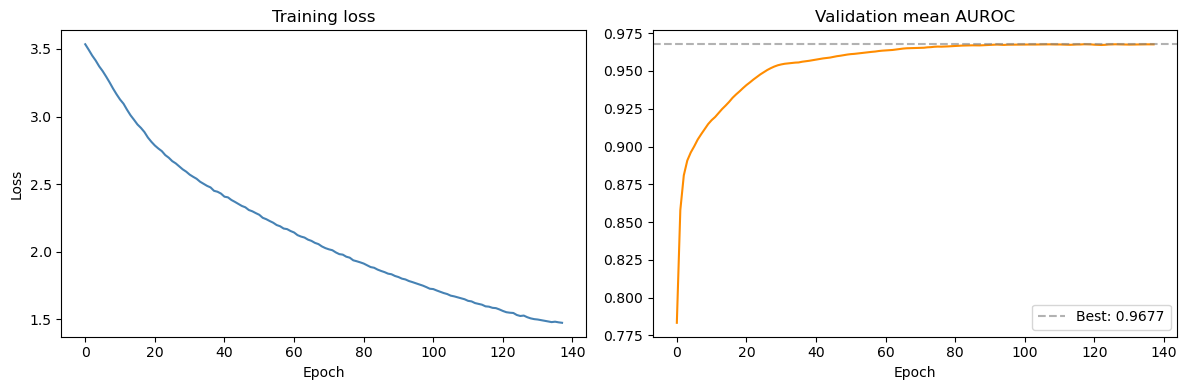

In [76]:
# ── Training curves ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], color="steelblue")
ax1.set_title("Training loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2.plot(history["val_auroc"], color="darkorange")
ax2.axhline(best_val_auroc, linestyle="--", color="gray", alpha=0.6,
            label=f"Best: {best_val_auroc:.4f}")
ax2.set_title("Validation mean AUROC"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

In [77]:
model.eval()
with torch.no_grad():
    logits      = model(data_dev.x_dict, data_dev.edge_index_dict)
    test_probs  = torch.sigmoid(logits[test_mask]).cpu().numpy()
    test_labels = data_dev["isolate"].y[test_mask].cpu().numpy()

test_metrics = compute_metrics(test_probs, test_labels, DRUG_COLS, thresholds=best_thresholds)

results_df = pd.DataFrame(test_metrics).T.round(4)
print("\n=== Test Results (threshold-tuned) ===")
print(results_df.to_string())
results_df


=== Test Results (threshold-tuned) ===
                       AUROC   AUPRC  Sensitivity  Specificity      F1  Threshold
INH_BINARY_PHENOTYPE  0.9694  0.9708       0.9265       0.9788  0.9507        0.8
RIF_BINARY_PHENOTYPE  0.9690  0.9471       0.9605       0.9440  0.9374        0.5
EMB_BINARY_PHENOTYPE  0.9616  0.8761       0.9375       0.9314  0.8535        0.8


,AUROC,AUPRC,Sensitivity,Specificity,F1,Threshold
INH_BINARY_PHENOTYPE,0.9694,0.9708,0.9265,0.9788,0.9507,0.8
RIF_BINARY_PHENOTYPE,0.9690,0.9471,0.9605,0.9440,0.9374,0.5
EMB_BINARY_PHENOTYPE,0.9616,0.8761,0.9375,0.9314,0.8535,0.8


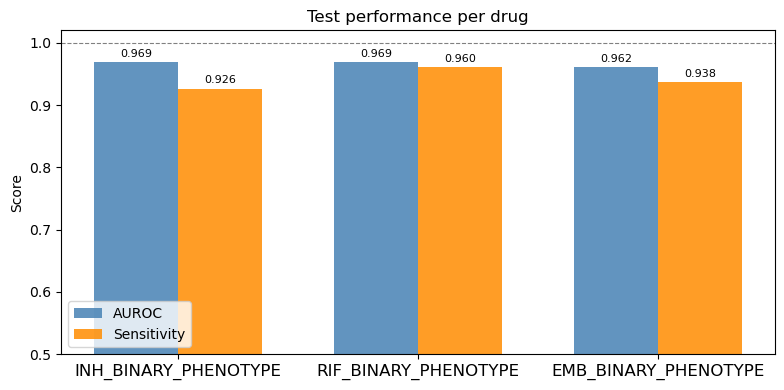

In [78]:
# ── Bar chart of per-drug AUROC ──────────────────────────────────────────
drugs  = list(test_metrics.keys())
aurocs = [test_metrics[d]["AUROC"] for d in drugs]
sens   = [test_metrics[d]["Sensitivity"] for d in drugs]

x = np.arange(len(drugs))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - w/2, aurocs, w, label="AUROC",       color="steelblue",  alpha=0.85)
bars2 = ax.bar(x + w/2, sens,   w, label="Sensitivity", color="darkorange", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(drugs, fontsize=12)
ax.set_ylim(0.5, 1.02)
ax.set_ylabel("Score"); ax.set_title("Test performance per drug")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.legend()
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("test_performance.png", dpi=120, bbox_inches="tight")
plt.show()

In [79]:
model.eval()
with torch.no_grad():
    _ = model(data_dev.x_dict, data_dev.edge_index_dict)

gene_attn_per_layer = model.get_gene_attention()

for l_idx, layer_attn in enumerate(gene_attn_per_layer):
    genes_sorted = list(layer_attn.keys())
    weights      = list(layer_attn.values())
    print(f"\nLayer {l_idx+1} — top genes by type-level attention:")
    for g, w in zip(genes_sorted[:10], weights[:10]):
        bar = "█" * int(w * 300)
        print(f"  {g:<8} {w:.4f}  {bar}")


Layer 1 — top genes by type-level attention:
  ahpC     0.0217  ██████
  in_ahpC  0.0217  ██████
  eis      0.0217  ██████
  in_eis   0.0217  ██████
  embA     0.0217  ██████
  in_embA  0.0217  ██████
  embB     0.0217  ██████
  in_embB  0.0217  ██████
  embC     0.0217  ██████
  in_embC  0.0217  ██████

Layer 2 — top genes by type-level attention:
  ahpC     0.0217  ██████
  in_ahpC  0.0217  ██████
  eis      0.0217  ██████
  in_eis   0.0217  ██████
  embA     0.0217  ██████
  in_embA  0.0217  ██████
  embB     0.0217  ██████
  in_embB  0.0217  ██████
  embC     0.0217  ██████
  in_embC  0.0217  ██████


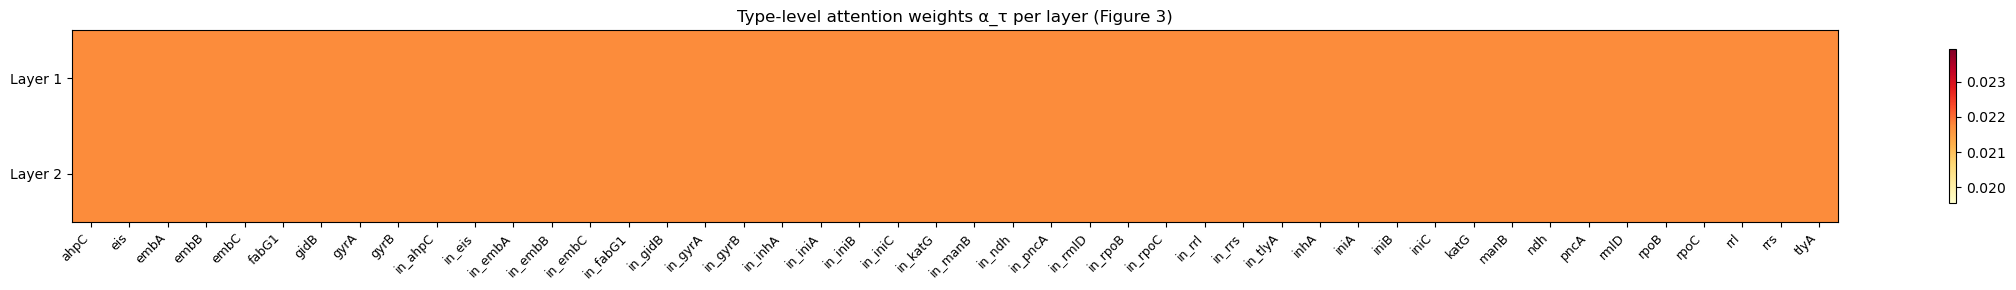

In [80]:
# ── Heatmap: gene attention across layers ────────────────────────────────
all_genes = sorted(set(g for la in gene_attn_per_layer for g in la))
attn_matrix = np.array([[la.get(g, 0.0) for g in all_genes]
                          for la in gene_attn_per_layer])

fig, ax = plt.subplots(figsize=(max(10, len(all_genes) * 0.5), 3))
im = ax.imshow(attn_matrix, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(all_genes))); ax.set_xticklabels(all_genes, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(gene_attn_per_layer)))
ax.set_yticklabels([f"Layer {i+1}" for i in range(len(gene_attn_per_layer))])
ax.set_title("Type-level attention weights α_τ per layer (Figure 3)")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("gene_attention_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

In [81]:
@torch.no_grad()
def snp_attention_rankings(model, data, top_k=10):
    model.eval()
    results = {}
    for l_idx, layer in enumerate(model.layers):
        for (src, rel, dst), conv in layer.conv.convs.items():
            gene = rel.replace("has_", "")
            ei   = data.edge_index_dict.get((src, rel, dst))
            if ei is None: continue
            x_src = data.x_dict.get(src)
            x_dst = data.x_dict.get(dst)
            if x_src is None or x_dst is None: continue
            try:
                _, (_, attn) = conv((x_src, x_dst), ei, return_attention_weights=True)
            except Exception:
                continue
            attn_mean = attn.mean(dim=1).detach().cpu().numpy()
            dst_nodes = ei[1].cpu().numpy()
            snp_ids   = getattr(data[dst], "snp_ids", None)
            if snp_ids is None: continue
            n_snps = data[dst].x.shape[0]
            agg, cnt = np.zeros(n_snps), np.zeros(n_snps)
            for e_idx, si in enumerate(dst_nodes):
                agg[si] += attn_mean[e_idx]; cnt[si] += 1
            avg_attn = np.divide(agg, cnt, where=cnt > 0, out=np.zeros_like(agg))
            df = pd.DataFrame({"snp_id": snp_ids, "mean_attention": avg_attn})
            results[f"L{l_idx+1}_{gene}"] = df.sort_values("mean_attention", ascending=False).head(top_k)
    return results

snp_rankings = snp_attention_rankings(model, data_dev.cpu(), top_k=10)
# Show top SNPs for key genes
for key in list(snp_rankings.keys())[:6]:
    print(f"\n{key}:")
    print(snp_rankings[key].to_string(index=False))


L1_ahpC:
        snp_id  mean_attention
ahpC_G2726636A        0.142857
ahpC_G2726119A        0.125000
ahpC_A2726293G        0.125000
ahpC_C2726112T        0.111111
ahpC_C2726139T        0.083333
ahpC_C2726136T        0.066667
ahpC_C2726121T        0.066667
ahpC_G2726468A        0.062500
ahpC_C2726763T        0.045455
ahpC_G2726418A        0.045455

L1_eis:
       snp_id  mean_attention
eis_C2714432T        0.200000
eis_A2714523C        0.166667
eis_A2715399T        0.166667
eis_C2715555T        0.166667
eis_C2714211T        0.142857
eis_C2714265T        0.142857
eis_G2715347C        0.125000
eis_G2714673A        0.125000
eis_G2714109A        0.100000
eis_G2714955A        0.076923

L1_embA:
        snp_id  mean_attention
embA_C4244729T        0.200000
embA_G4244443A        0.166667
embA_C4244379T        0.166667
embA_T4243324C        0.166667
embA_C4244167T        0.142857
embA_C4243412T        0.142857
embA_C4243532T        0.125000
embA_G4243833A        0.111111
embA_G4243482T       

In [82]:
@torch.no_grad()
def isolate_attention(model, data, isolate_idx):
    model.eval()
    results = {}
    for l_idx, layer in enumerate(model.layers):
        for (src, rel, dst), conv in layer.conv.convs.items():
            # Per-isolate SNP attention is defined on isolate -> gene edges only.
            if src != "isolate" or not rel.startswith("has_"):
                continue

            gene = rel.replace("has_", "")
            ei   = data.edge_index_dict.get((src, rel, dst))
            if ei is None: continue
            iso_mask = (ei[0] == isolate_idx)
            if iso_mask.sum() == 0: continue
            x_src = data.x_dict.get(src)
            x_dst = data.x_dict.get(dst)
            if x_src is None or x_dst is None:
                continue
            try:
                _, (_, attn) = conv((x_src, x_dst), ei, return_attention_weights=True)
            except Exception:
                continue
            attn_iso  = attn[iso_mask].mean(dim=1).detach().cpu().numpy()
            snp_idxs  = ei[1][iso_mask].cpu().numpy()
            snp_ids   = getattr(data[dst], "snp_ids", None)
            if snp_ids is None:
                continue

            valid = [int(i) for i in snp_idxs if 0 <= int(i) < len(snp_ids)]
            if not valid:
                continue
            results[f"L{l_idx+1}_{gene}"] = pd.DataFrame({
                "snp_id":    [snp_ids[i] for i in valid],
                "attention": attn_iso[:len(valid)]
            }).sort_values("attention", ascending=False)
    return results

# Change index to inspect a different isolate
ISOLATE_IDX = 0
iso_attn = isolate_attention(model, data_dev.cpu(), isolate_idx=ISOLATE_IDX)

iso_ids = data["isolate"].isolate_ids
iso_name = iso_ids[ISOLATE_IDX] if iso_ids else str(ISOLATE_IDX)
print(f"Attention scores for isolate: {iso_name}")
for key, df in list(iso_attn.items())[:4]:
    print(f"\n  {key}:")
    print(df.head(5).to_string(index=False))

Attention scores for isolate: ERS1987021

  L1_embC:
        snp_id  attention
embC_G4242803C   0.000524
embC_C4242643T   0.000078

  L1_gyrA:
     snp_id  attention
gyrA_G7585C   0.000118
gyrA_G9304A   0.000098
gyrA_G7362C   0.000092

  L1_iniC:
        snp_id  attention
iniC_C3989135T    0.00081

  L1_manB:
        snp_id  attention
manB_C4156099A   0.000084
